#  Unsupervised learning on Country Data
- Country Segmentation using K-Means, DBSCAN and PCA
## Project Objective

The objective of this project is to apply unsupervised machine learning techniques to classify countries based on socio-economic and health indicators. Using clustering algorithms such as K-Means and DBSCAN, countries are grouped into similar categories to identify patterns in development, healthcare, and economic performance. Principal Component Analysis (PCA) is used to visualize the clusters and better understand the underlying structure of the dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# Load Dataset

In [2]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [24]:
print("Dataset Shape:", df.shape)

Dataset Shape: (167, 12)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# Check Missing Values

In [4]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

# Data Cleaning

In [5]:
df = df.copy()

df.columns = [col.strip().lower() for col in df.columns]

df.drop_duplicates(inplace=True)

for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.fillna(df.median(numeric_only=True), inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (167, 10)


# Exploratory Data Analysis (EDA)

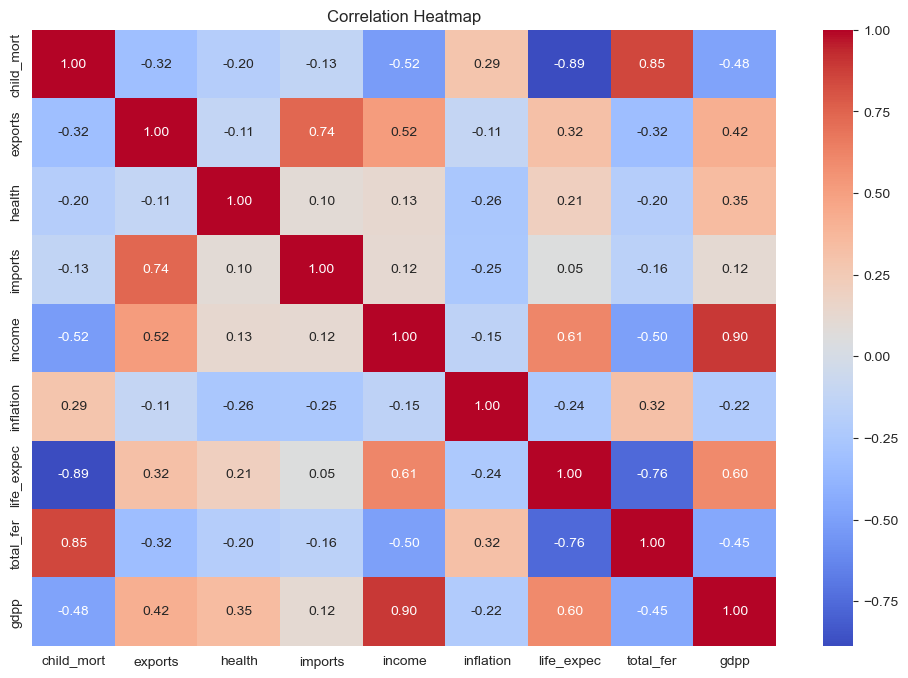

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

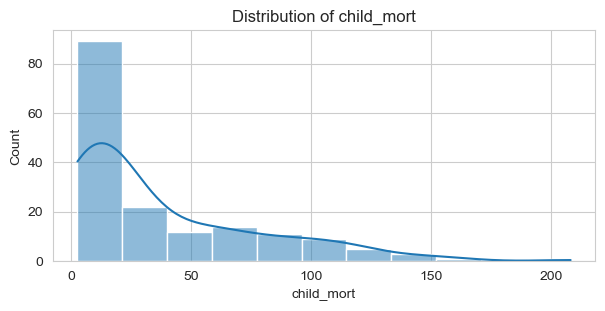

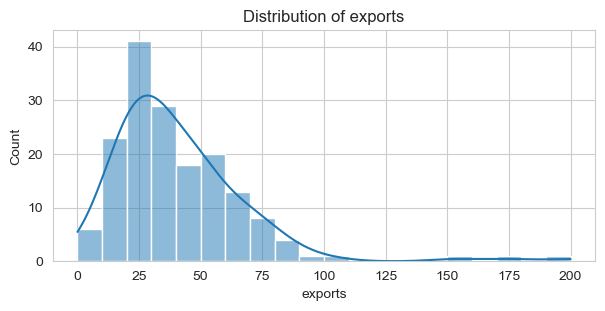

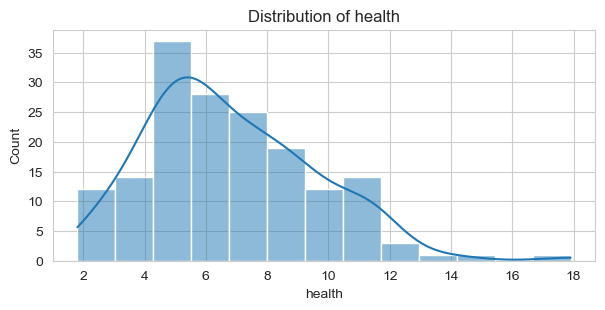

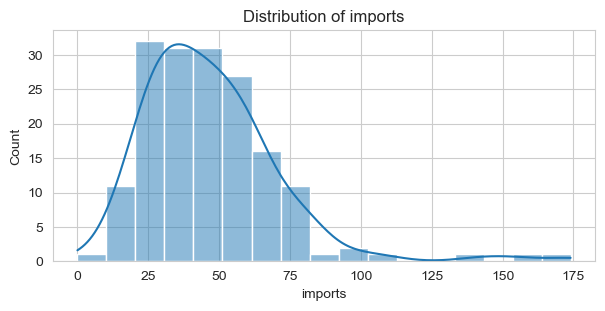

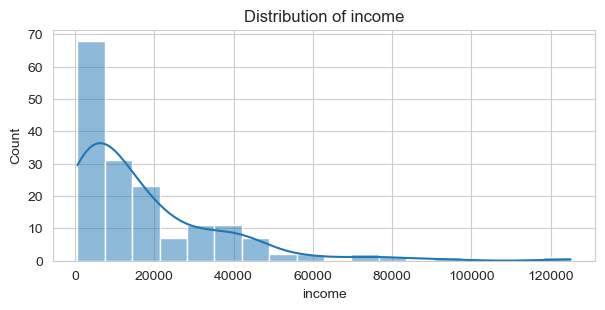

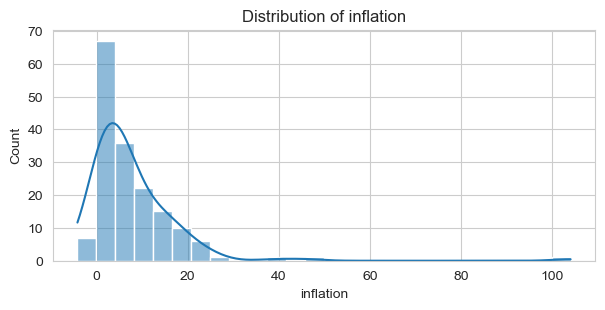

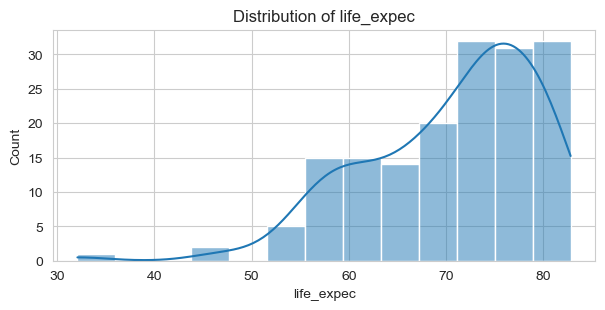

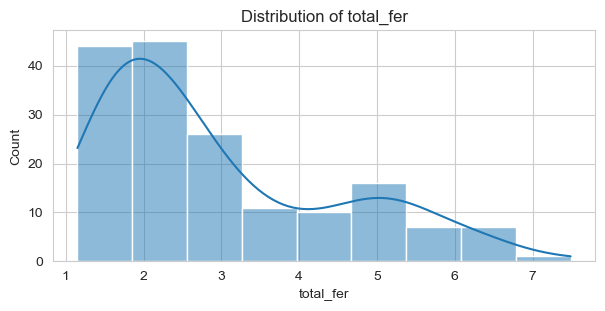

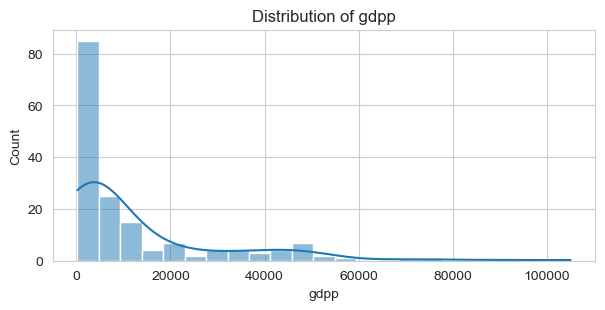

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(7,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

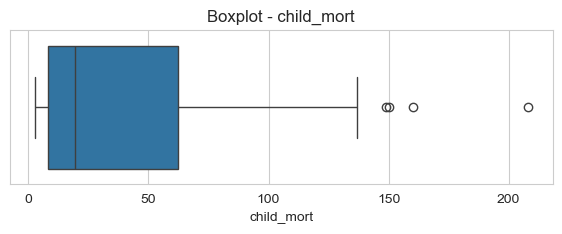

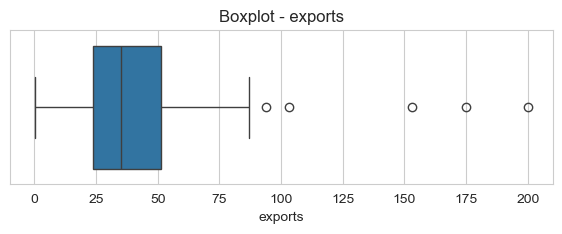

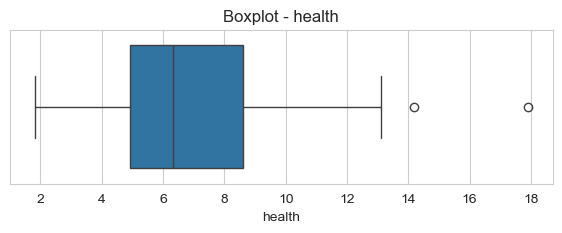

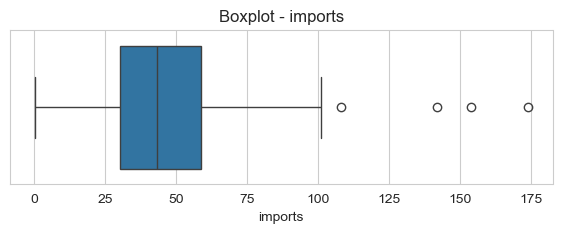

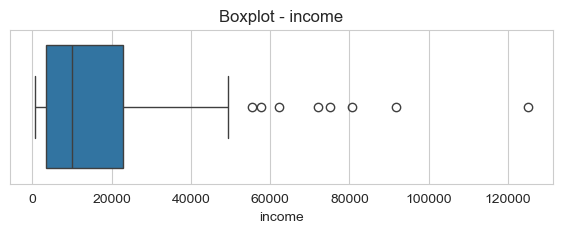

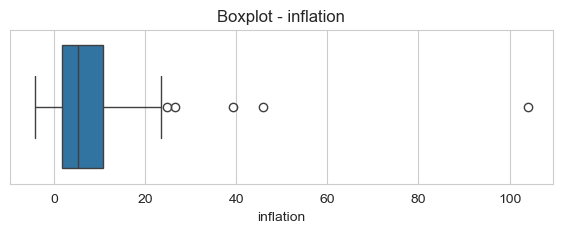

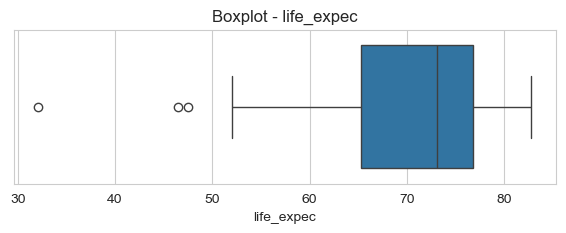

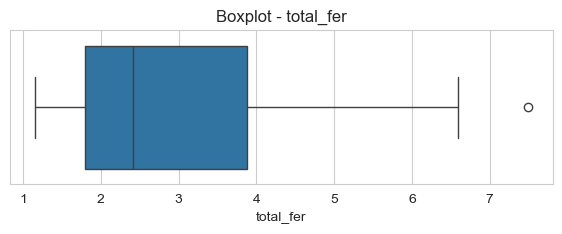

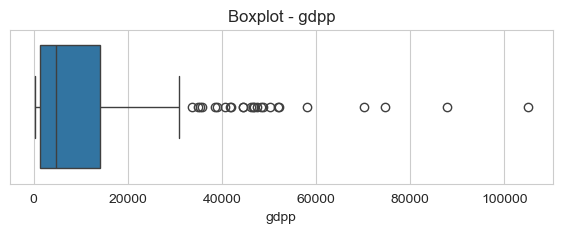

In [8]:
for col in numeric_cols:
    plt.figure(figsize=(7,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

# Feature Scaling

In [9]:
features = df.drop("country", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

X_scaled.shape

(167, 9)

In [10]:
import warnings
warnings.filterwarnings("ignore")
inertia = []

K = range(1,11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

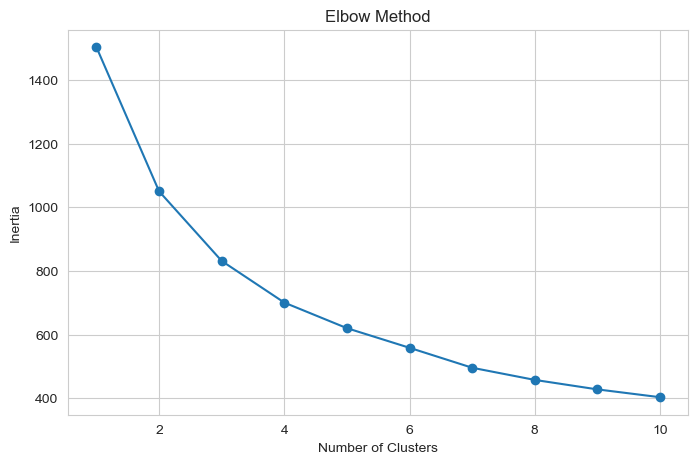

In [11]:
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette Score Analysis

In [12]:
for k in range(2,11):
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    print(f"K={k}  Silhouette Score={score:.4f}")

K=2  Silhouette Score=0.2874
K=3  Silhouette Score=0.2833
K=4  Silhouette Score=0.2960
K=5  Silhouette Score=0.2993
K=6  Silhouette Score=0.2287
K=7  Silhouette Score=0.2477
K=8  Silhouette Score=0.2388
K=9  Silhouette Score=0.2073
K=10  Silhouette Score=0.2022


# Training K-Means Model

In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [14]:
score = silhouette_score(
    X_scaled,
    df["kmeans_cluster"]
)

print("Silhouette Score:", round(score,4))

Silhouette Score: 0.2833


In [15]:
df["kmeans_cluster"].value_counts()

kmeans_cluster
2    84
1    47
0    36
Name: count, dtype: int64

In [16]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PCA1": X_pca[:,0],
    "PCA2": X_pca[:,1],
    "Cluster": df["kmeans_cluster"]
})

pca_df.head()

,PCA1,PCA2,Cluster
0,-2.913025,0.095621,1
1,0.429911,-0.588156,2
2,-0.285225,-0.455174,2
3,-2.932423,1.695555,1
4,1.033576,0.136659,2


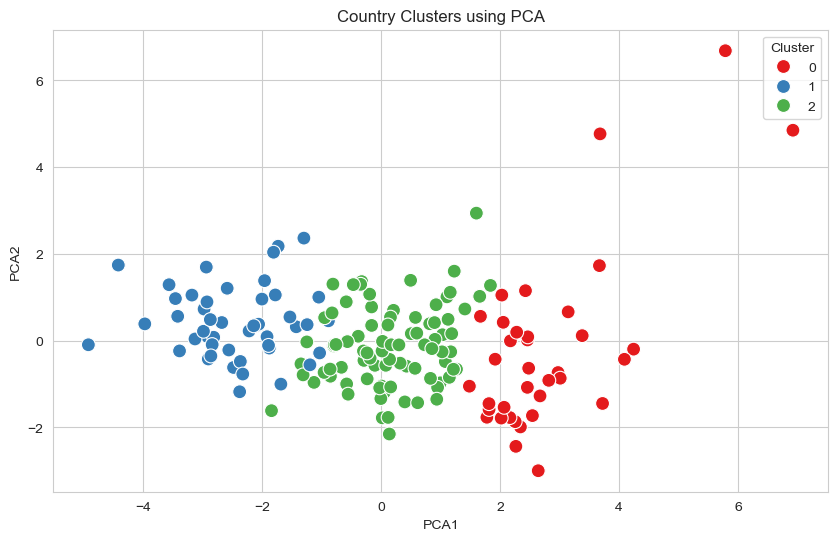

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Country Clusters using PCA")
plt.show()

In [18]:
cluster_profile = (
    df.groupby("kmeans_cluster")
      .mean(numeric_only=True)
      .round(2)
)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


### Cluster Interpretation

- Cluster 0 represents highly developed countries with high GDP and income.
- Cluster 1 represents developing countries with moderate economic indicators.
- Cluster 2 represents underdeveloped countries with lower GDP, lower income, and higher child mortality.

In [19]:
for cluster in sorted(df["kmeans_cluster"].unique()):
    
    print("\n")
    print("="*60)
    print(f"CLUSTER {cluster}")
    print("="*60)
    
    countries = df[df["kmeans_cluster"]==cluster]["country"].tolist()
    
    print(countries)



CLUSTER 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']


CLUSTER 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', '

# DBSCAN Clustering 

In [20]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"].value_counts()

dbscan_cluster
 0    137
-1     30
Name: count, dtype: int64

In [21]:
pca_dbscan = pd.DataFrame({
    "PCA1": X_pca[:,0],
    "PCA2": X_pca[:,1],
    "Cluster": df["dbscan_cluster"]
})

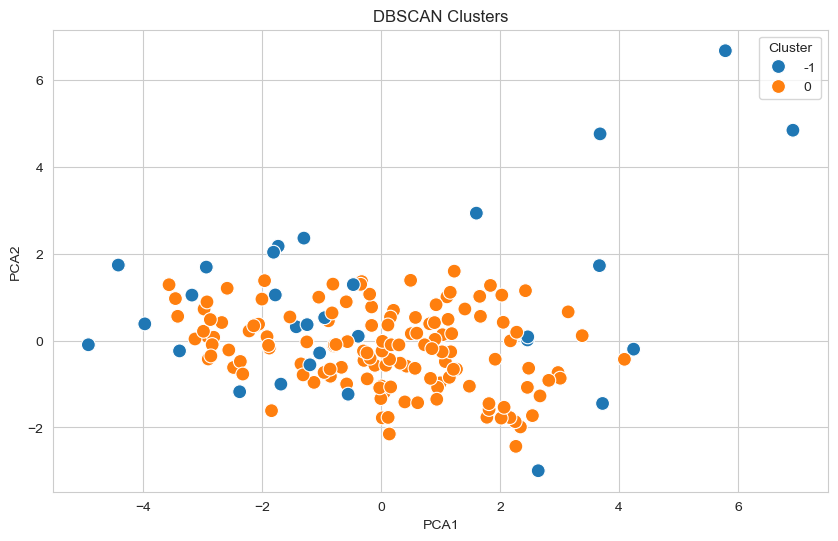

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_dbscan,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    s=100
)

plt.title("DBSCAN Clusters")
plt.show()

# Top Countries Needing Aid

In [23]:
aid_countries = df.sort_values(
    by=[
        "child_mort",
        "income",
        "gdpp"
    ],
    ascending=[
        False,
        True,
        True
    ]
)

aid_countries[
    [
        "country",
        "child_mort",
        "income",
        "life_expec",
        "gdpp"
    ]
].head(20)

,country,child_mort,income,life_expec,gdpp
66,Haiti,208.0,1500,32.1,662
132,Sierra Leone,160.0,1220,55.0,399
32,Chad,150.0,1930,56.5,897
31,Central African Republic,149.0,888,47.5,446
97,Mali,137.0,1870,59.5,708
113,Nigeria,130.0,5150,60.5,2330
112,Niger,123.0,814,58.8,348
3,Angola,119.0,5900,60.1,3530
37,"Congo, Dem. Rep.",116.0,609,57.5,334
25,Burkina Faso,116.0,1430,57.9,575


# Final Insights

- Countries were successfully grouped into meaningful clusters based on socio-economic and health indicators.

- Developed countries were characterized by high income, high GDP per capita, higher life expectancy, and lower child mortality rates.

- Developing countries formed a separate cluster with moderate economic and social indicators.

- Underdeveloped countries showed lower income levels, lower GDP per capita, higher fertility rates, and higher child mortality.

- PCA visualization confirmed a clear separation among clusters, validating the effectiveness of the clustering approach.

- A positive relationship was observed between income and GDP per capita, indicating that wealthier nations generally provide better living standards.

- Countries with higher child mortality rates generally exhibited lower life expectancy and weaker economic conditions.

- The clustering results can help identify countries that may require greater economic support, healthcare improvements, and international aid.

- Unsupervised learning techniques such as K-Means and DBSCAN proved effective in discovering hidden patterns within the country dataset.